Total de acidentes para análise: 236

Distribuição da classificação dos acidentes:
classificacao_acidente
Com Vítimas Feridas    173
Sem Vítimas             40
Com Vítimas Fatais      23
Name: count, dtype: int64

ANÁLISE DE CORRESPONDÊNCIA MÚLTIPLA (MCA)

Autovalores e variância explicada:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.341         2.97%                      2.97%
1              0.310         2.70%                      5.67%
2              0.285         2.48%                      8.14%
3              0.270         2.35%                     10.49%
4              0.265         2.30%                     12.79%
5              0.257         2.24%                     15.03%
6              0.243         2.11%                     17.14%
7              0.236         2.05%                     19.19%
8              0.233         2.03%                     21.22%
9              0.230      

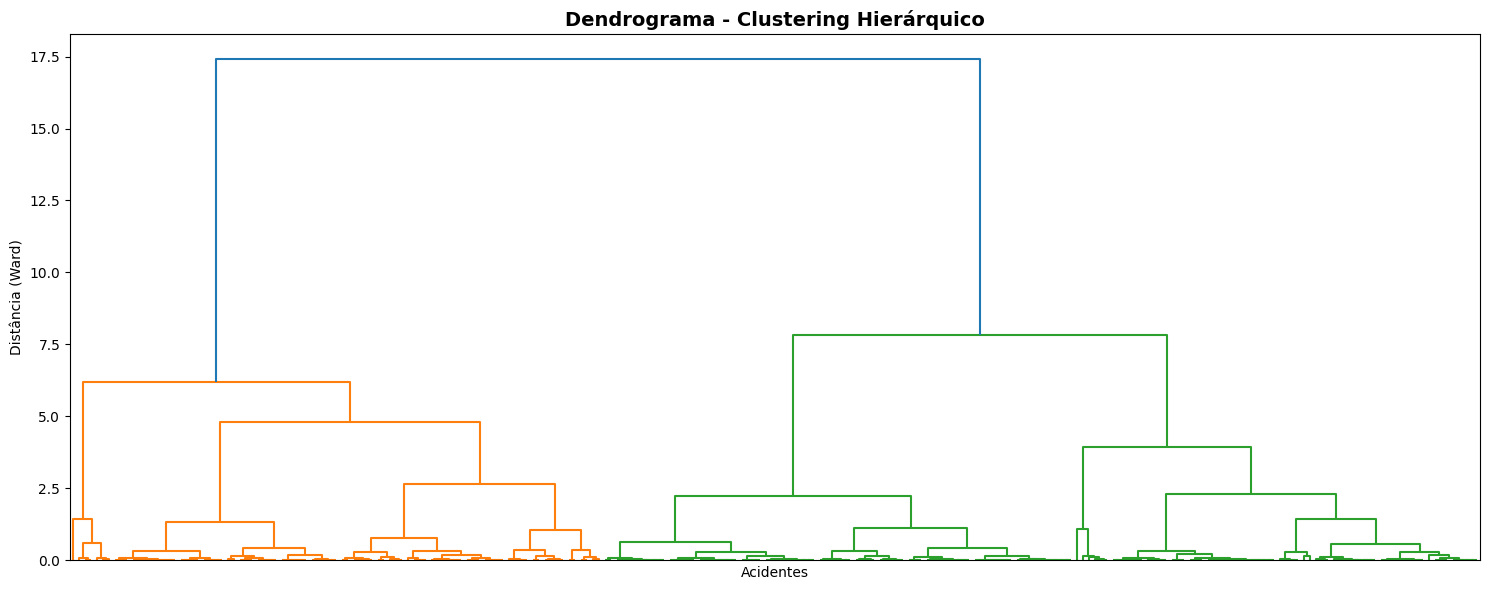


Dendrograma salvo como 'dendrograma_mca_cluster.png'

Distribuição dos clusters:
cluster
0    89
1    68
2    79
Name: count, dtype: int64

VISUALIZAÇÃO DOS CLUSTERS


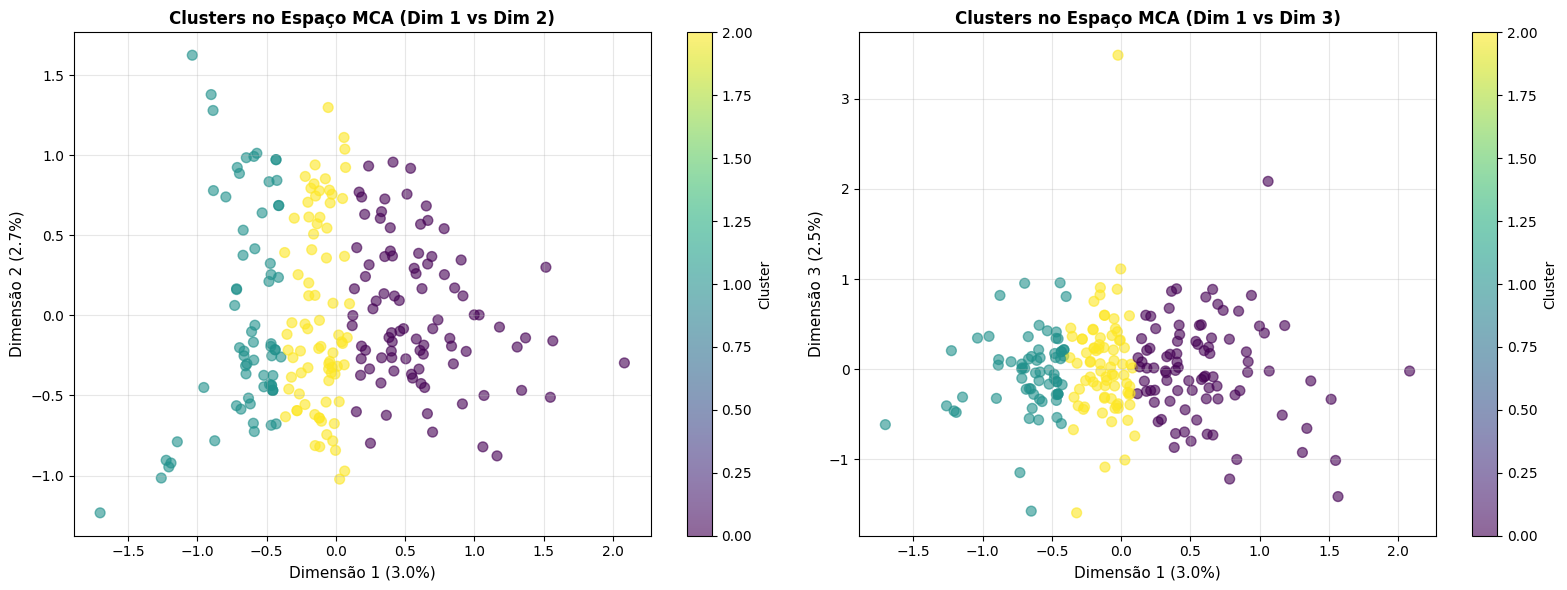


Visualizações salvas como 'clusters_mca_visualization.png'

CARACTERIZAÇÃO DOS CLUSTERS

Associação entre variáveis e clusters (ordenado por V de Cramér):
              variable       chi2      p_value  cramers_v
              uso_solo 119.293603 1.246589e-26   0.710972
           tracado_via 166.520815 4.429871e-07   0.593968
         tipo_acidente 121.206806 6.401138e-13   0.506749
        causa_acidente  90.519030 3.558843e-06   0.437924
            tipo_pista  78.204885 4.180188e-16   0.407048
classificacao_acidente  34.972679 4.705764e-07   0.272203
condicao_metereologica  24.242321 4.282693e-02   0.226629
              fase_dia  17.916532 6.444206e-03   0.194830

Variáveis com forte associação aos clusters (V > 0.15): ['uso_solo', 'tracado_via', 'tipo_acidente', 'causa_acidente', 'tipo_pista', 'classificacao_acidente', 'condicao_metereologica', 'fase_dia']

PERFIL DETALHADO DOS CLUSTERS

CLUSTER 0 (n=89 acidentes)

causa_acidente:
                                               C

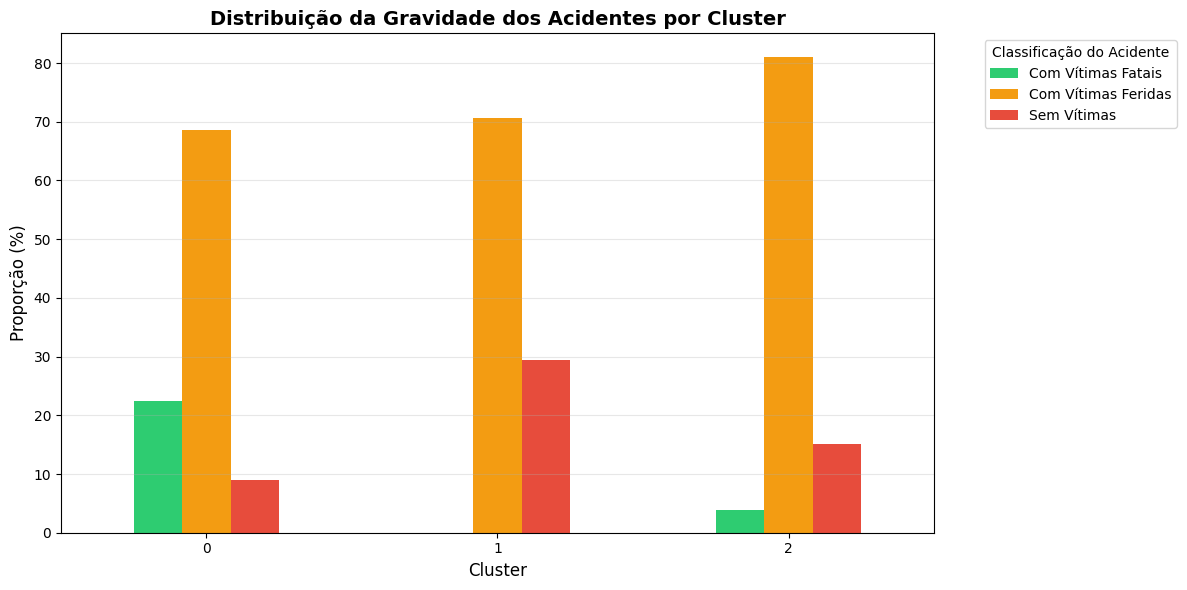


Gráfico salvo como 'gravidade_por_cluster.png'

EXPORTANDO RESULTADOS

Dataset com clusters salvo como 'acidentes_clusters_mca.csv'
Sumário estatístico salvo como 'sumario_clusters_mca.txt'

ANÁLISE CONCLUÍDA COM SUCESSO!


In [5]:
import pandas as pd
import numpy as np
import prince
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ============================================================================

# Carregar dados
df = pd.read_csv('/home/jobsr/Documents/GitHub/MultivariadaII/data/acidente_transito.csv', sep=';', low_memory=False)

# Filtrar apenas causas relacionadas à infraestrutura viária
causas_infraestrutura = [
    'Iluminação deficiente',
    'Demais falhas na via',
    'Pista esburacada',
    'Falta de acostamento',
    'Acesso irregular',
    'Acumulo de água sobre o pavimento',
    'Acumulo de areia ou detritos sobre o pavimento',
    'Acumulo de óleo sobre o pavimento',
    'Falta de elemento de contenção que evite a saída do leito carroçável',
    'Restrição de visibilidade em curvas verticais',
    'Restrição de visibilidade em curvas horizontais',
    'Sistema de drenagem ineficiente',
    'Declive acentuado',
    'Curva acentuada',
    'Sinalização mal posicionada',
    'Desvio temporário',
    'Ausência de sinalização',
    'Afundamento ou ondulação no pavimento',
    'Acostamento em desnível',
    'Deficiência do Sistema de Iluminação/Sinalização',
    'Pista Escorregadia'
]

# Filtrar base
df_infra = df[df['causa_acidente'].isin(causas_infraestrutura)].copy()

# Agregar por acidente (id) para evitar duplicação de pessoas
# Selecionar variáveis relevantes para análise
variaveis_mca = [
    'causa_acidente',
    'classificacao_acidente',
    'tipo_pista',
    'tracado_via',
    'fase_dia',
    'condicao_metereologica',
    'tipo_acidente',
    'uso_solo'
]

# Criar dataset agregado por id de acidente
# Para gravidade, usar a classificação mais grave do acidente
gravidade_ordem = {'Sem Vítimas': 1, 'Com Vítimas Feridas': 2, 'Com Vítimas Fatais': 3}

df_agg = df_infra.groupby('id').agg({
    'causa_acidente': 'first',
    'classificacao_acidente': lambda x: max(x, key=lambda y: gravidade_ordem.get(y, 0)),
    'tipo_pista': 'first',
    'tracado_via': 'first',
    'fase_dia': 'first',
    'condicao_metereologica': 'first',
    'tipo_acidente': 'first',
    'uso_solo': 'first',
    'mortos': 'sum',
    'feridos_graves': 'sum',
    'feridos_leves': 'sum'
}).reset_index()

# Remover valores ausentes
df_mca = df_agg[variaveis_mca].dropna()

print(f"Total de acidentes para análise: {len(df_mca)}")
print(f"\nDistribuição da classificação dos acidentes:")
print(df_mca['classificacao_acidente'].value_counts())

# ============================================================================
# 2. MULTIPLE CORRESPONDENCE ANALYSIS (MCA)
# ============================================================================

print("\n" + "="*80)
print("ANÁLISE DE CORRESPONDÊNCIA MÚLTIPLA (MCA)")
print("="*80)

# Configurar MCA
n_components = 10  # Número de componentes a extrair
mca = prince.MCA(
    n_components=n_components,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Ajustar MCA
mca.fit(df_mca)

# Resumo dos autovalores
print("\nAutovalores e variância explicada:")
print(mca.eigenvalues_summary)

# **CORREÇÃO: Converter strings com % para valores numéricos**
# Extrair a coluna de variância cumulativa e converter
variance_cumsum_str = mca.eigenvalues_summary['% of variance (cumulative)'].values

# Remover o símbolo % e converter para float, depois dividir por 100
variance_cumsum = np.array([float(str(v).replace('%', '')) / 100 for v in variance_cumsum_str])

# Encontrar número de dimensões para explicar 80% da variância
n_dims_80 = np.argmax(variance_cumsum >= 0.80) + 1
print(f"\nNúmero de dimensões necessárias para explicar 80% da variância: {n_dims_80}")
print(f"Variância explicada com {n_dims_80} dimensões: {variance_cumsum[n_dims_80-1]*100:.2f}%")

# Obter coordenadas dos indivíduos (acidentes) nas componentes principais
row_coords = mca.row_coordinates(df_mca)
print(f"\nDimensões das coordenadas: {row_coords.shape}")

# ============================================================================
# 3. ANÁLISE DE CLUSTER HIERÁRQUICO
# ============================================================================

print("\n" + "="*80)
print("ANÁLISE DE CLUSTER HIERÁRQUICO")
print("="*80)

# Usar as primeiras dimensões que explicam 80% da variância
X_mca = row_coords.iloc[:, :n_dims_80].values

# Padronizar as coordenadas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mca)

# Realizar clustering hierárquico com método de Ward
linkage_matrix = linkage(X_scaled, method='ward')

# Plotar dendrograma para identificar número ideal de clusters
plt.figure(figsize=(15, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)
plt.title('Dendrograma - Clustering Hierárquico', fontsize=14, fontweight='bold')
plt.xlabel('Acidentes')
plt.ylabel('Distância (Ward)')
plt.tight_layout()
plt.savefig('dendrograma_mca_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nDendrograma salvo como 'dendrograma_mca_cluster.png'")

# Definir número de clusters (ajustar conforme dendrograma)
n_clusters = 3  # Ajustar baseado na observação do dendrograma

# Aplicar clustering hierárquico
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc.fit_predict(X_scaled)

# Adicionar clusters ao dataframe
df_mca['cluster'] = clusters

print(f"\nDistribuição dos clusters:")
print(df_mca['cluster'].value_counts().sort_index())

# ============================================================================
# 4. VISUALIZAÇÃO DOS CLUSTERS NO ESPAÇO MCA
# ============================================================================

print("\n" + "="*80)
print("VISUALIZAÇÃO DOS CLUSTERS")
print("="*80)

# Extrair as porcentagens de variância para os labels dos eixos
variance_pct = mca.eigenvalues_summary['% of variance'].values
variance_pct = [float(str(v).replace('%', '')) for v in variance_pct]

# Plot dos clusters nas duas primeiras dimensões
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Dim 1 vs Dim 2
scatter1 = axes[0].scatter(
    row_coords.iloc[:, 0], 
    row_coords.iloc[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=50
)
axes[0].set_xlabel(f'Dimensão 1 ({variance_pct[0]:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'Dimensão 2 ({variance_pct[1]:.1f}%)', fontsize=11)
axes[0].set_title('Clusters no Espaço MCA (Dim 1 vs Dim 2)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Dim 1 vs Dim 3
scatter2 = axes[1].scatter(
    row_coords.iloc[:, 0], 
    row_coords.iloc[:, 2],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=50
)
axes[1].set_xlabel(f'Dimensão 1 ({variance_pct[0]:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'Dimensão 3 ({variance_pct[2]:.1f}%)', fontsize=11)
axes[1].set_title('Clusters no Espaço MCA (Dim 1 vs Dim 3)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('clusters_mca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nVisualizações salvas como 'clusters_mca_visualization.png'")

# ============================================================================
# 5. CARACTERIZAÇÃO DOS CLUSTERS
# ============================================================================

print("\n" + "="*80)
print("CARACTERIZAÇÃO DOS CLUSTERS")
print("="*80)

# Função para calcular associação entre clusters e variáveis categóricas
def test_chi2_cluster(df, var_name, cluster_col='cluster'):
    """Calcula teste qui-quadrado entre cluster e variável categórica"""
    contingency_table = pd.crosstab(df[cluster_col], df[var_name])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Calcular V de Cramér
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape[0], contingency_table.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    return {
        'variable': var_name,
        'chi2': chi2,
        'p_value': p_value,
        'cramers_v': cramers_v
    }

# Testar associação de todas as variáveis com clusters
association_results = []
for var in variaveis_mca:
    result = test_chi2_cluster(df_mca, var)
    association_results.append(result)

df_associations = pd.DataFrame(association_results).sort_values('cramers_v', ascending=False)
print("\nAssociação entre variáveis e clusters (ordenado por V de Cramér):")
print(df_associations.to_string(index=False))

# Identificar variáveis mais importantes (V de Cramér > 0.15)
vars_importantes = df_associations[df_associations['cramers_v'] > 0.15]['variable'].tolist()
print(f"\nVariáveis com forte associação aos clusters (V > 0.15): {vars_importantes}")

# ============================================================================
# 6. PERFIL DETALHADO DE CADA CLUSTER
# ============================================================================

print("\n" + "="*80)
print("PERFIL DETALHADO DOS CLUSTERS")
print("="*80)

for cluster_id in sorted(df_mca['cluster'].unique()):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} (n={len(df_mca[df_mca['cluster']==cluster_id])} acidentes)")
    print(f"{'='*80}")
    
    cluster_data = df_mca[df_mca['cluster'] == cluster_id]
    
    # Para cada variável, mostrar distribuição no cluster vs. geral
    for var in variaveis_mca:
        print(f"\n{var}:")
        
        # Distribuição no cluster
        cluster_dist = cluster_data[var].value_counts(normalize=True)
        
        # Distribuição geral
        overall_dist = df_mca[var].value_counts(normalize=True)
        
        # Calcular sobre-representação (ratio)
        comparison = pd.DataFrame({
            f'Cluster {cluster_id} (%)': cluster_dist * 100,
            'Geral (%)': overall_dist * 100
        }).fillna(0)
        comparison['Ratio'] = comparison[f'Cluster {cluster_id} (%)'] / (comparison['Geral (%)'] + 0.001)
        
        # Mostrar apenas top 3 categorias mais sobre-representadas
        top_categories = comparison.nlargest(3, 'Ratio')
        print(top_categories.round(2).to_string())

# ============================================================================
# 7. ANÁLISE ESPECÍFICA: GRAVIDADE POR CLUSTER
# ============================================================================

print("\n" + "="*80)
print("ANÁLISE DE GRAVIDADE POR CLUSTER")
print("="*80)

# Tabela cruzada de classificação por cluster
crosstab_gravidade = pd.crosstab(
    df_mca['cluster'], 
    df_mca['classificacao_acidente'],
    normalize='index'
) * 100

print("\nDistribuição da gravidade por cluster (%):")
print(crosstab_gravidade.round(2))

# Visualizar gravidade por cluster
fig, ax = plt.subplots(figsize=(12, 6))
crosstab_gravidade.plot(kind='bar', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Proporção (%)', fontsize=12)
ax.set_title('Distribuição da Gravidade dos Acidentes por Cluster', fontsize=14, fontweight='bold')
ax.legend(title='Classificação do Acidente', bbox_to_anchor=(1.05, 1))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gravidade_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nGráfico salvo como 'gravidade_por_cluster.png'")

# ============================================================================
# 8. EXPORTAR RESULTADOS
# ============================================================================

print("\n" + "="*80)
print("EXPORTANDO RESULTADOS")
print("="*80)

# Adicionar cluster ao dataset original agregado
df_agg_resultado = df_agg.copy()
df_agg_resultado = df_agg_resultado.loc[df_mca.index]
df_agg_resultado['cluster'] = clusters

# Salvar
df_agg_resultado.to_csv('acidentes_clusters_mca.csv', index=False)
print("\nDataset com clusters salvo como 'acidentes_clusters_mca.csv'")

# Salvar sumário estatístico
with open('sumario_clusters_mca.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("SUMÁRIO DA ANÁLISE MCA + CLUSTER\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Total de acidentes analisados: {len(df_mca)}\n")
    f.write(f"Número de clusters identificados: {n_clusters}\n")
    f.write(f"Dimensões MCA usadas: {n_dims_80}\n")
    f.write(f"Variância explicada: {variance_cumsum[n_dims_80-1]:.2f}%\n\n")
    
    f.write("Distribuição dos clusters:\n")
    f.write(df_mca['cluster'].value_counts().sort_index().to_string())
    f.write("\n\n")
    
    f.write("Associação variáveis-clusters:\n")
    f.write(df_associations.to_string(index=False))

print("Sumário estatístico salvo como 'sumario_clusters_mca.txt'")

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)
